In [23]:
import pandas as pd;


In [24]:
df= pd.read_csv("..\Crop_Yield_Prediction.csv")

In [25]:
df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Yield
0,90,42,43,20.879744,82.002744,6.502985,202.935536,Rice,7000
1,85,58,41,21.770462,80.319644,7.038096,226.655537,Rice,5000
2,60,55,44,23.004459,82.320763,7.840207,263.964248,Rice,7000
3,74,35,40,26.491096,80.158363,6.980401,242.864034,Rice,7000
4,78,42,42,20.130175,81.604873,7.628473,262.717340,Rice,120000


In [26]:
df.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Yield
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,2689.228182
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,3710.361267
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,2.000000
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,950.000000
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,1825.000000
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,3500.000000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,120000.000000


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   str    
 8   Yield        2200 non-null   int64  
dtypes: float64(4), int64(4), str(1)
memory usage: 154.8 KB


In [29]:
df.isnull().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Rainfall       0
Crop           0
Yield          0
dtype: int64

In [30]:
df.isna().mean() * 100

Nitrogen       0.0
Phosphorus     0.0
Potassium      0.0
Temperature    0.0
Humidity       0.0
pH_Value       0.0
Rainfall       0.0
Crop           0.0
Yield          0.0
dtype: float64

In [31]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.nunique()

Nitrogen        137
Phosphorus      117
Potassium        73
Temperature    2200
Humidity       2200
pH_Value       2200
Rainfall       2200
Crop             22
Yield           502
dtype: int64

In [35]:
df['Crop'].unique()

<StringArray>
[       'Rice',       'Maize',    'ChickPea', 'KidneyBeans',  'PigeonPeas',
   'MothBeans',    'MungBean',   'Blackgram',      'Lentil', 'Pomegranate',
      'Banana',       'Mango',      'Grapes',  'Watermelon',   'Muskmelon',
       'Apple',      'Orange',      'Papaya',     'Coconut',      'Cotton',
        'Jute',      'Coffee']
Length: 22, dtype: str

In [37]:
df["Crop"].nunique()

22

In [39]:
df['Crop'].value_counts()

Crop
Rice           100
Maize          100
ChickPea       100
KidneyBeans    100
PigeonPeas     100
MothBeans      100
MungBean       100
Blackgram      100
Lentil         100
Pomegranate    100
Banana         100
Mango          100
Grapes         100
Watermelon     100
Muskmelon      100
Apple          100
Orange         100
Papaya         100
Coconut        100
Cotton         100
Jute           100
Coffee         100
Name: count, dtype: int64

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

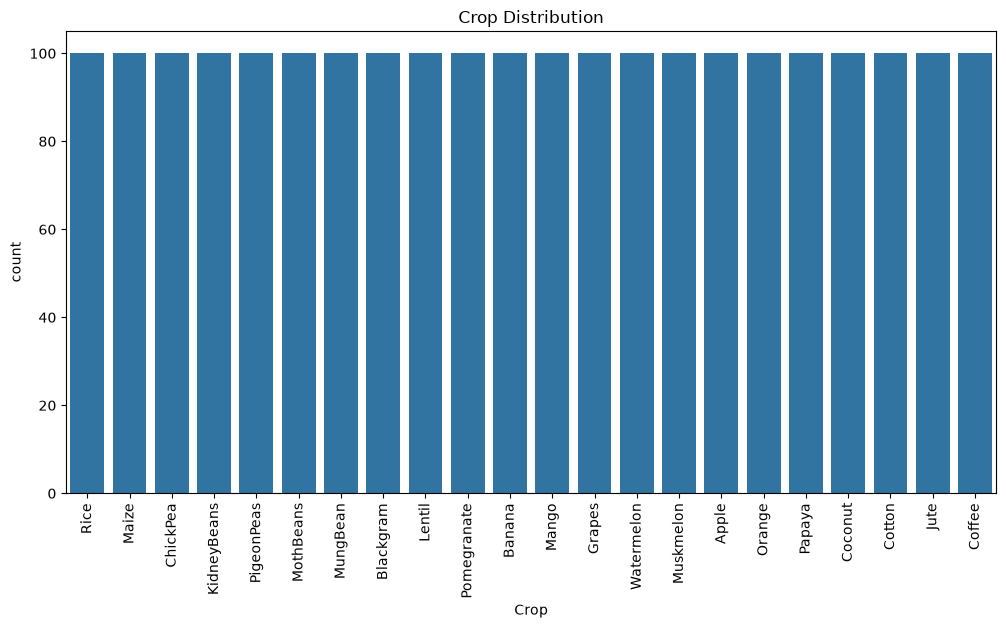

In [41]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="Crop")
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()

In [43]:
numeric_features= df.select_dtypes(include="number").columns
numeric_features

Index(['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity',
       'pH_Value', 'Rainfall', 'Yield'],
      dtype='str')

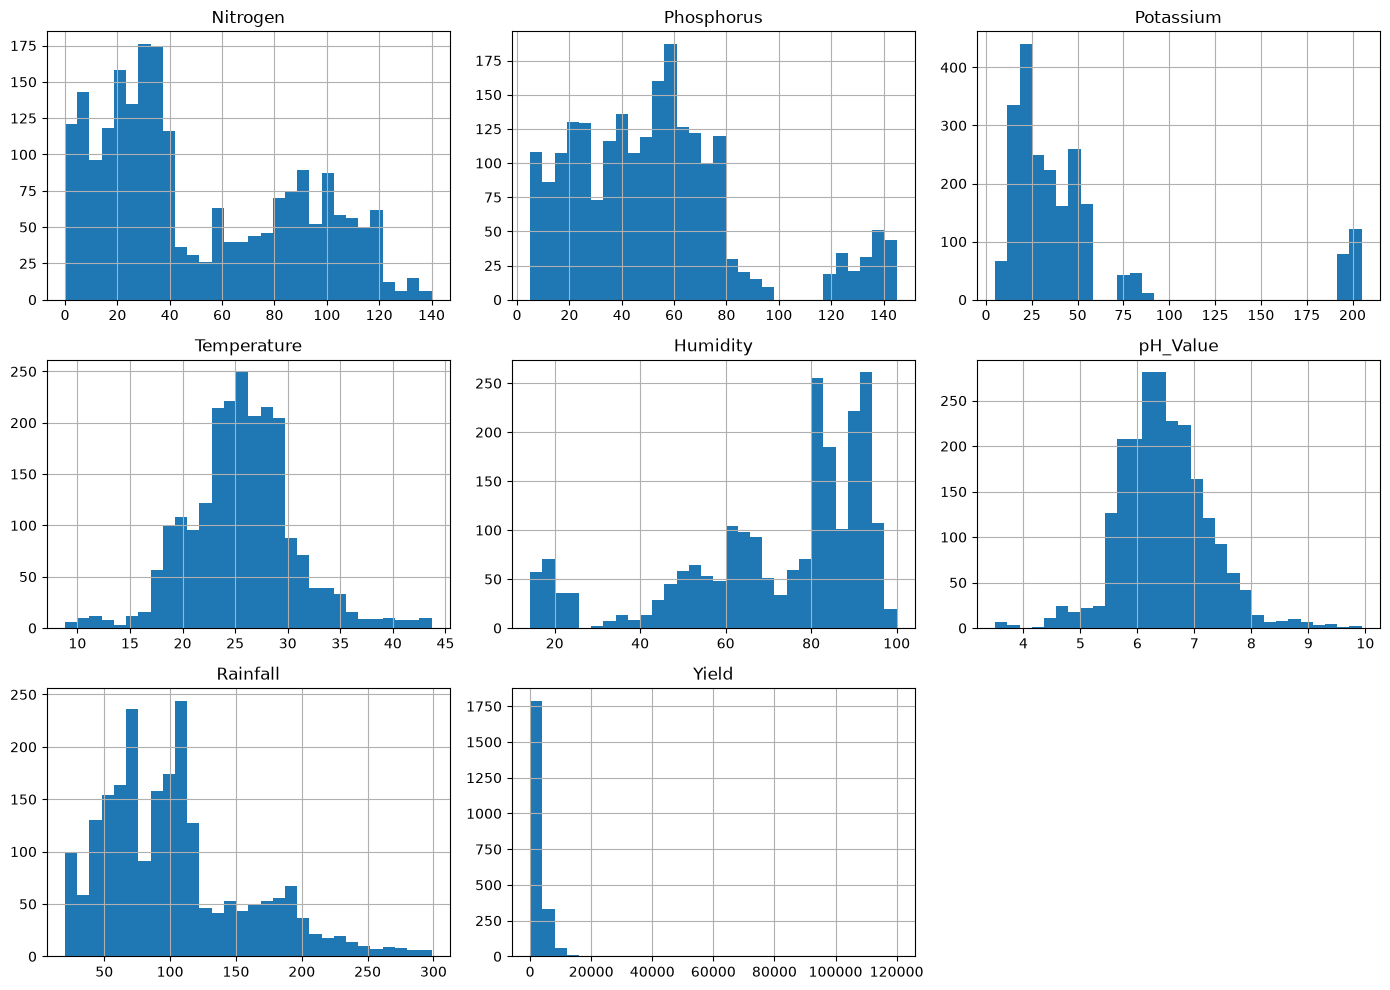

In [44]:
df[numeric_features].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

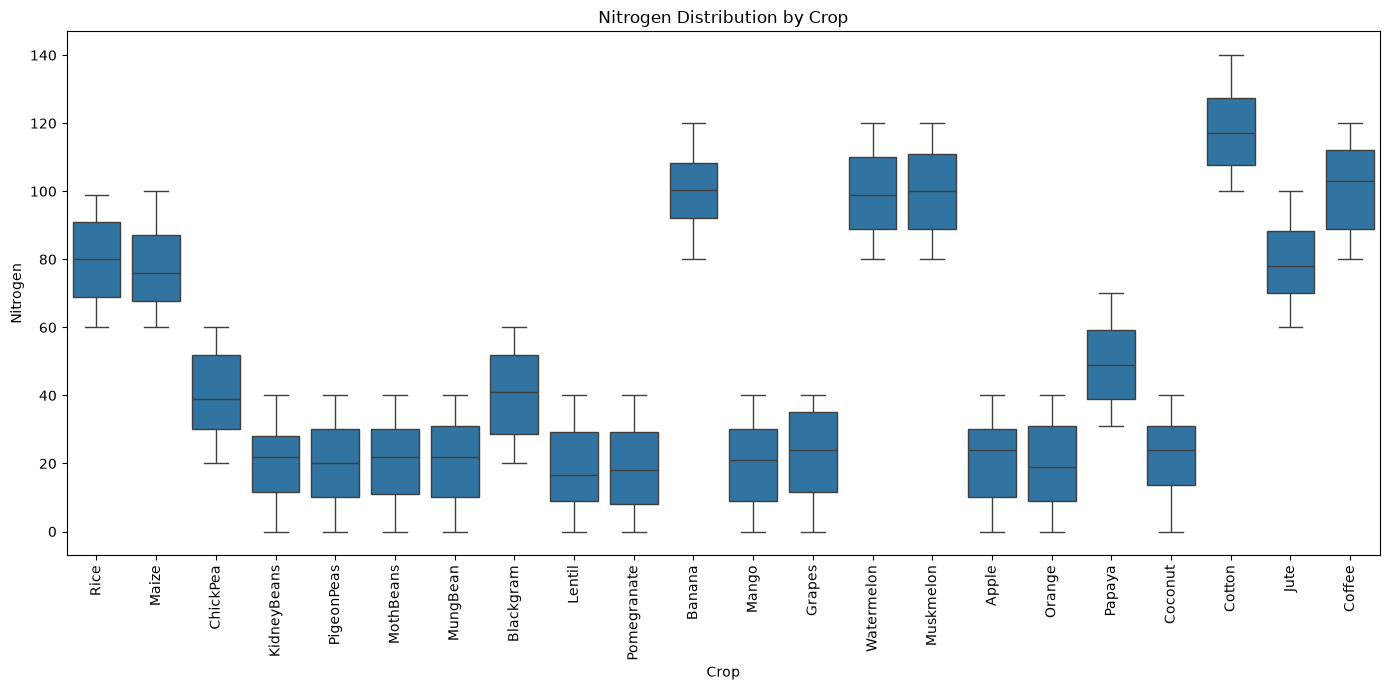

In [45]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df,
    x="Crop",
    y="Nitrogen"
)

plt.xticks(rotation=90)
plt.title("Nitrogen Distribution by Crop")
plt.tight_layout()
plt.show()

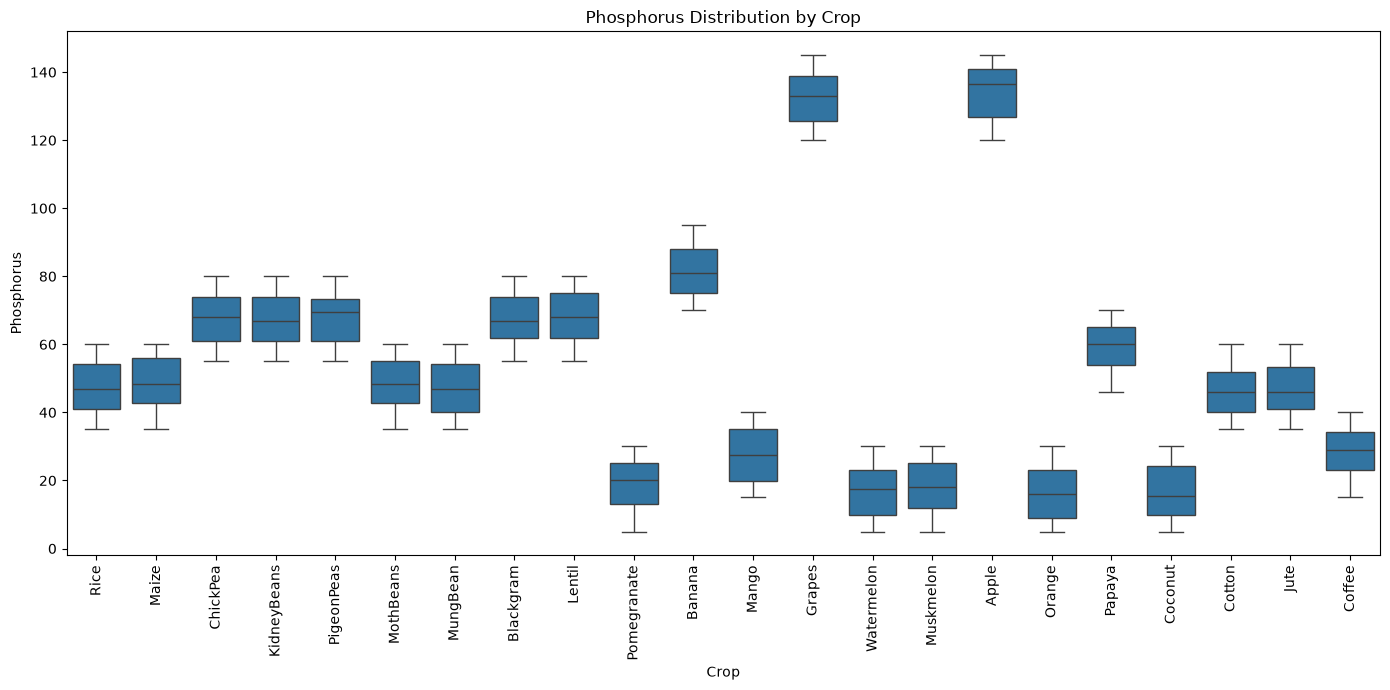

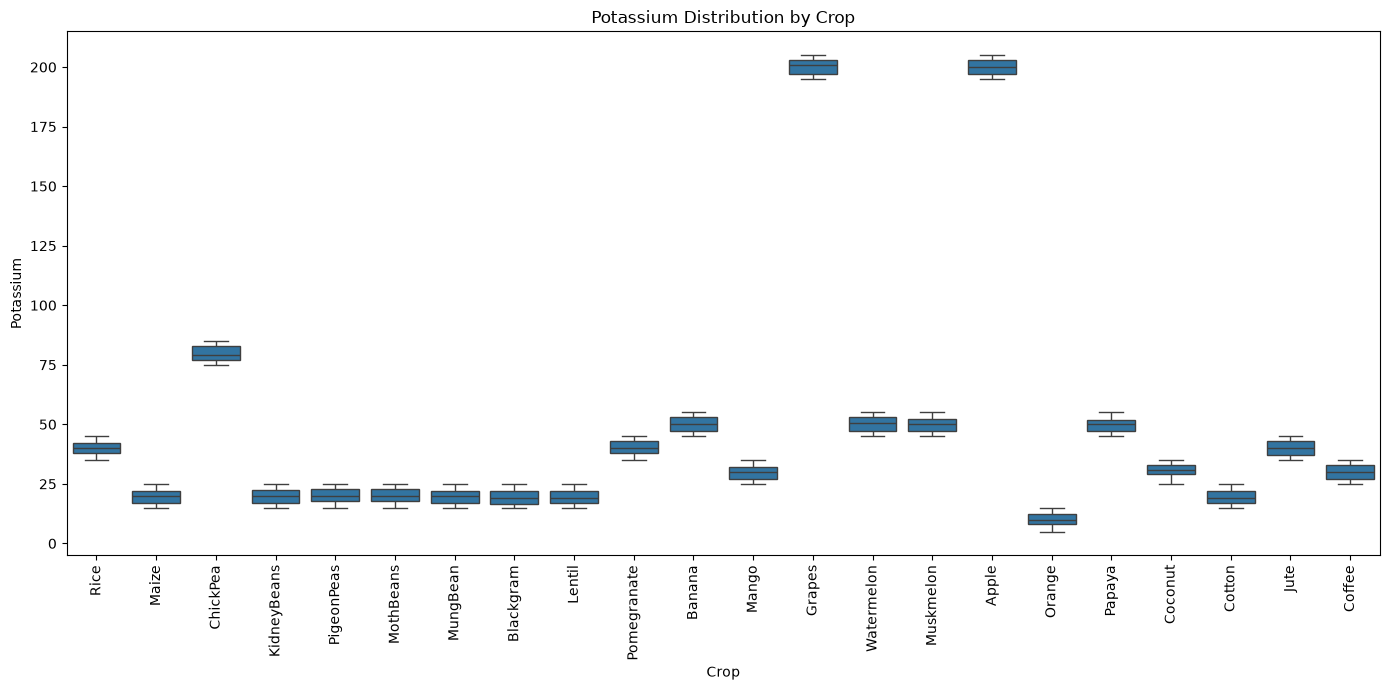

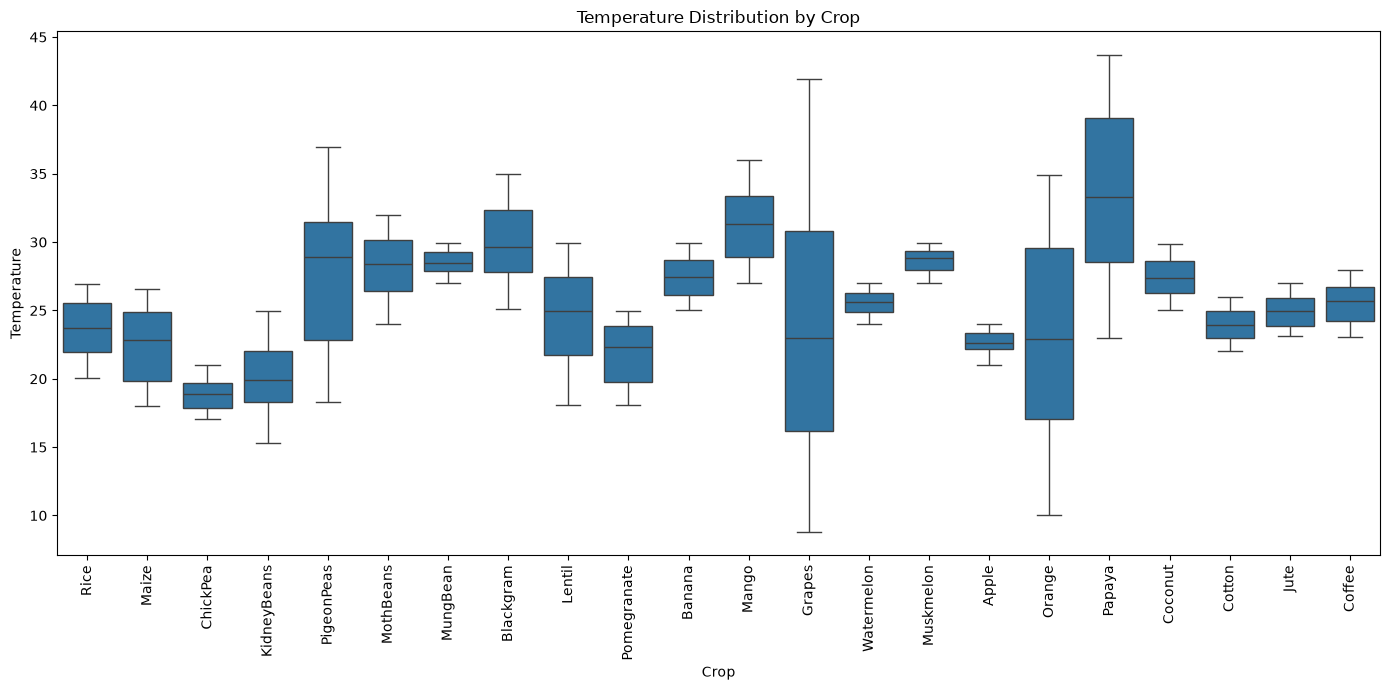

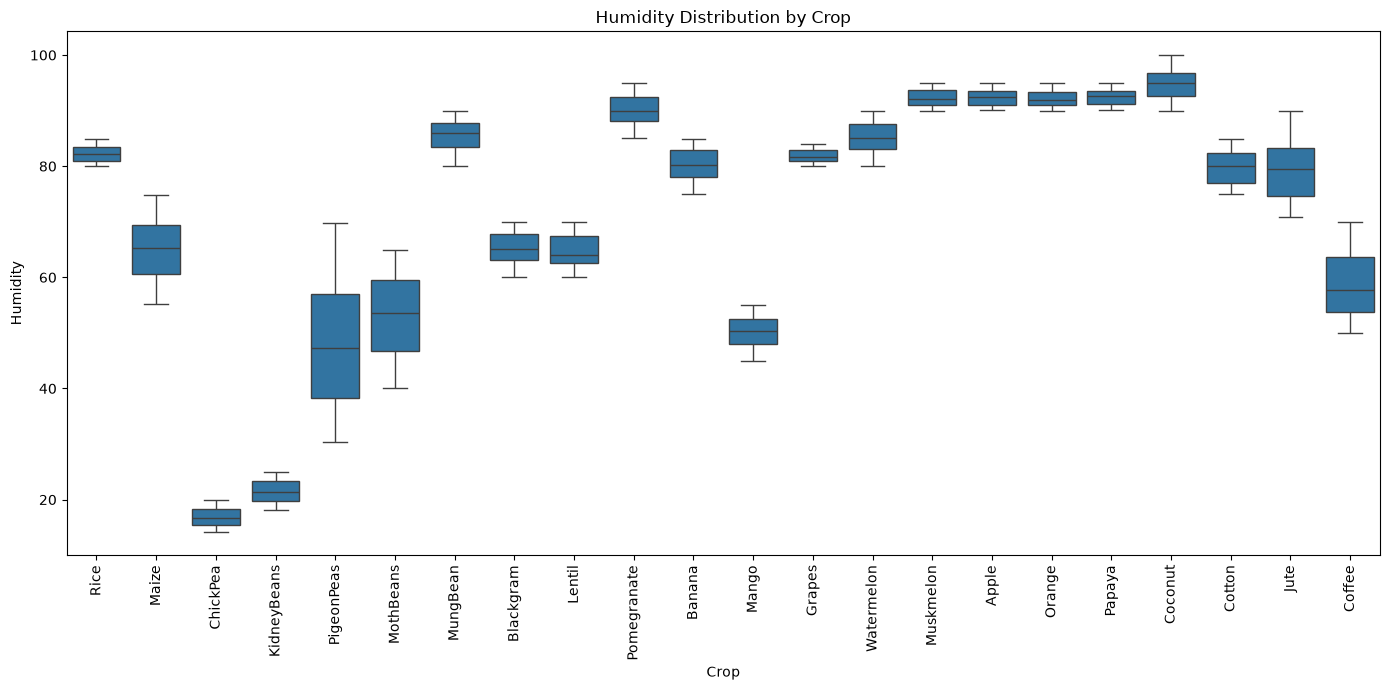

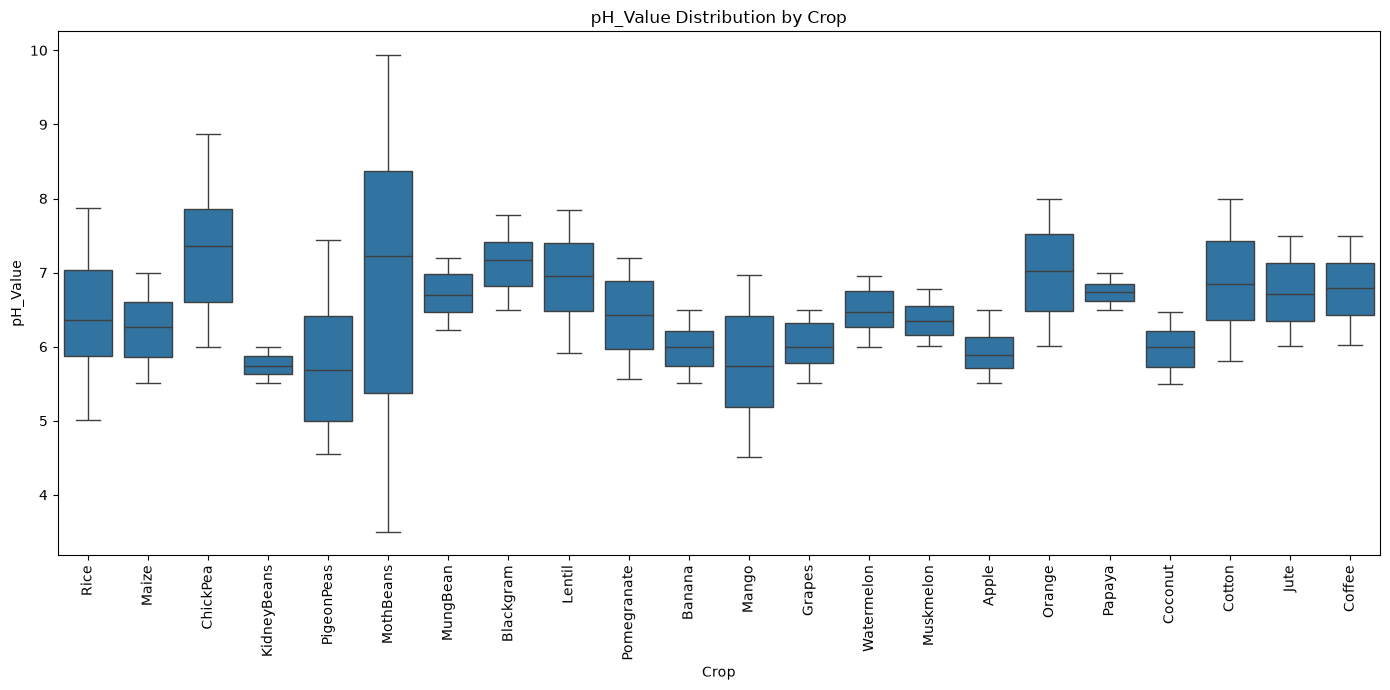

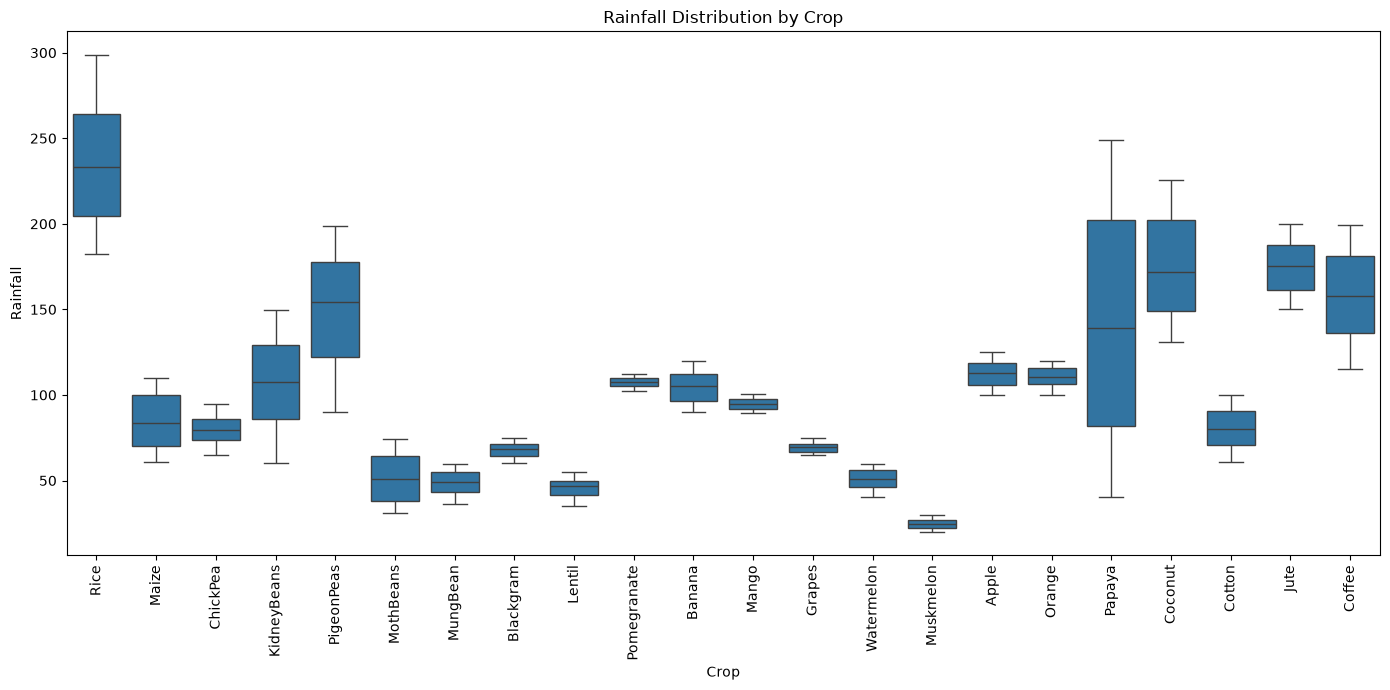

In [47]:
features = [
    "Phosphorus",
    "Potassium",
    "Temperature",
    "Humidity",
    "pH_Value",
    "Rainfall"
]

for feature in features:
    plt.figure(figsize=(14,7))
    sns.boxplot(
        data=df,
        x='Crop',
        y=feature
    )
    plt.xticks(rotation=90)
    plt.title(f"{feature} Distribution by Crop")
    plt.tight_layout()
    plt.show()

In [48]:
corr=df.select_dtypes(include="number").corr()
corr

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Yield
Nitrogen,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020,-0.001302
Phosphorus,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839,-0.023683
Potassium,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461,-0.021923
Temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084,-0.029044
Humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423,-0.041414
pH_Value,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069,-0.033548
Rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000,0.058847
Yield,-0.001302,-0.023683,-0.021923,-0.029044,-0.041414,-0.033548,0.058847,1.000000


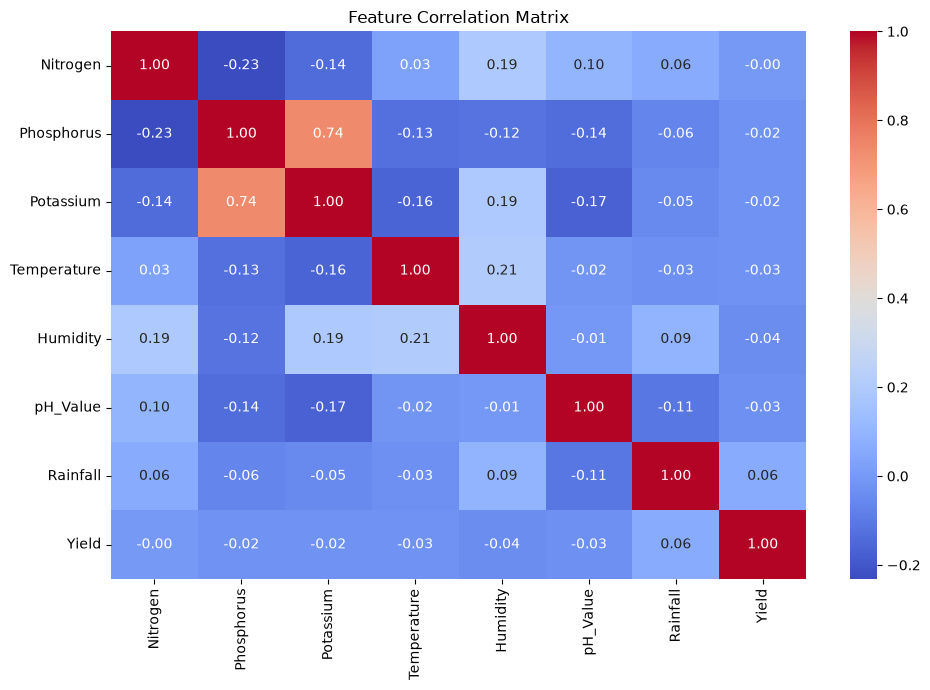

In [49]:
plt.figure(figsize=(10,7))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"

)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [50]:
df.groupby("Crop")["Nitrogen"].agg(
    ["mean", "median", "std", "min", "max"]
).sort_values("mean")

,mean,median,std,min,max
Crop,,,,,
Lentil,18.77,16.5,12.196915,0,40
Pomegranate,18.87,18.0,12.617652,0,40
Orange,19.58,19.0,11.941930,0,40
Mango,20.07,21.0,12.329037,0,40
PigeonPeas,20.73,20.0,11.849950,0,40
KidneyBeans,20.75,22.0,10.834266,0,40
Apple,20.80,24.0,11.863704,0,40
MungBean,20.99,22.0,11.510641,0,40
MothBeans,21.44,22.0,11.343418,0,40


In [57]:
features=[
    "Phosphorus",
    "Potassium",
    "Temperature",
    "Humidity",
    "pH_Value",
    "Rainfall"
]

for feature in features:
    details=df.groupby("Crop")[feature].agg(
    ["mean", "median", "std", "min", "max"]
    ).sort_values("mean")
    print(details)

               mean  median       std  min  max
Crop                                           
Orange        16.55    16.0  7.691495    5   30
Coconut       16.93    15.5  8.357244    5   30
Watermelon    17.00    17.5  7.535773    5   30
Muskmelon     17.72    18.0  7.187363    5   30
Pomegranate   18.75    20.0  7.387370    5   30
Mango         27.18    27.5  7.663873   15   40
Coffee        28.74    29.0  7.276113   15   40
Cotton        46.24    46.0  7.348634   35   60
Jute          46.86    46.0  7.195706   35   60
MungBean      47.28    47.0  7.870261   35   60
Rice          47.58    47.0  7.904966   35   60
MothBeans     48.01    48.5  7.547151   35   60
Maize         48.44    48.5  8.010498   35   60
Papaya        59.05    60.0  7.057305   46   70
Blackgram     67.47    67.0  7.151259   55   80
KidneyBeans   67.54    67.0  7.571104   55   80
PigeonPeas    67.73    69.5  7.294463   55   80
ChickPea      67.79    68.0  7.498545   55   80
Lentil        68.36    68.0  7.335427   

In [58]:
df.groupby("Crop")["Yield"].agg(
    ["mean", "median", "std", "min", "max"]
).sort_values("mean")

,mean,median,std,min,max
Crop,,,,,
Orange,1391.20,935.0,1184.278777,220,5350
Cotton,1411.05,1027.5,1385.240980,250,9270
Apple,1704.25,1525.0,1258.852366,350,5850
Mango,1750.40,1010.0,1851.492393,200,8500
Jute,1789.90,987.5,1834.264499,240,7500
Lentil,2028.62,1450.0,1920.598711,2,9600
Papaya,2080.95,1700.0,1898.403728,280,9250
Blackgram,2131.43,1500.0,1876.068150,2,10000
Banana,2377.09,1500.0,2383.870586,300,10000


In [59]:
df["Yield"].value_counts().head(20)

Yield
1500    57
1000    56
500     55
3000    52
700     51
2000    50
900     48
800     44
2500    43
1400    40
1100    36
3500    35
1200    35
4000    35
1800    32
1300    31
3800    28
600     28
400     28
5000    27
Name: count, dtype: int64

In [60]:
df.nlargest(10, "Yield")[["Crop", "Yield"]]

,Crop,Yield
4,Rice,120000
460,PigeonPeas,32500
445,PigeonPeas,29250
1806,Coconut,29000
483,PigeonPeas,27750
941,Pomegranate,26500
86,Rice,22250
463,PigeonPeas,21750
451,PigeonPeas,21500
87,Rice,20500


In [61]:
df.groupby("Crop")["Yield"].agg(
    ["mean", "median", "std", "min", "max"]
).sort_values("mean", ascending=False)

,mean,median,std,min,max
Crop,,,,,
PigeonPeas,5272.17,3500.0,5935.465005,400,32500
Rice,4706.75,2335.0,12253.496396,300,120000
Watermelon,3969.28,2385.0,3084.307057,220,14509
Pomegranate,3455.25,2337.5,3955.615965,500,26500
MothBeans,3214.50,2750.0,1810.802253,1100,9800
KidneyBeans,3161.20,2435.0,2695.780197,550,20000
Muskmelon,3055.75,1979.0,2572.932000,300,11261
Grapes,2840.35,2335.0,2043.758660,120,10275
MungBean,2718.00,2450.0,1493.466749,700,8200


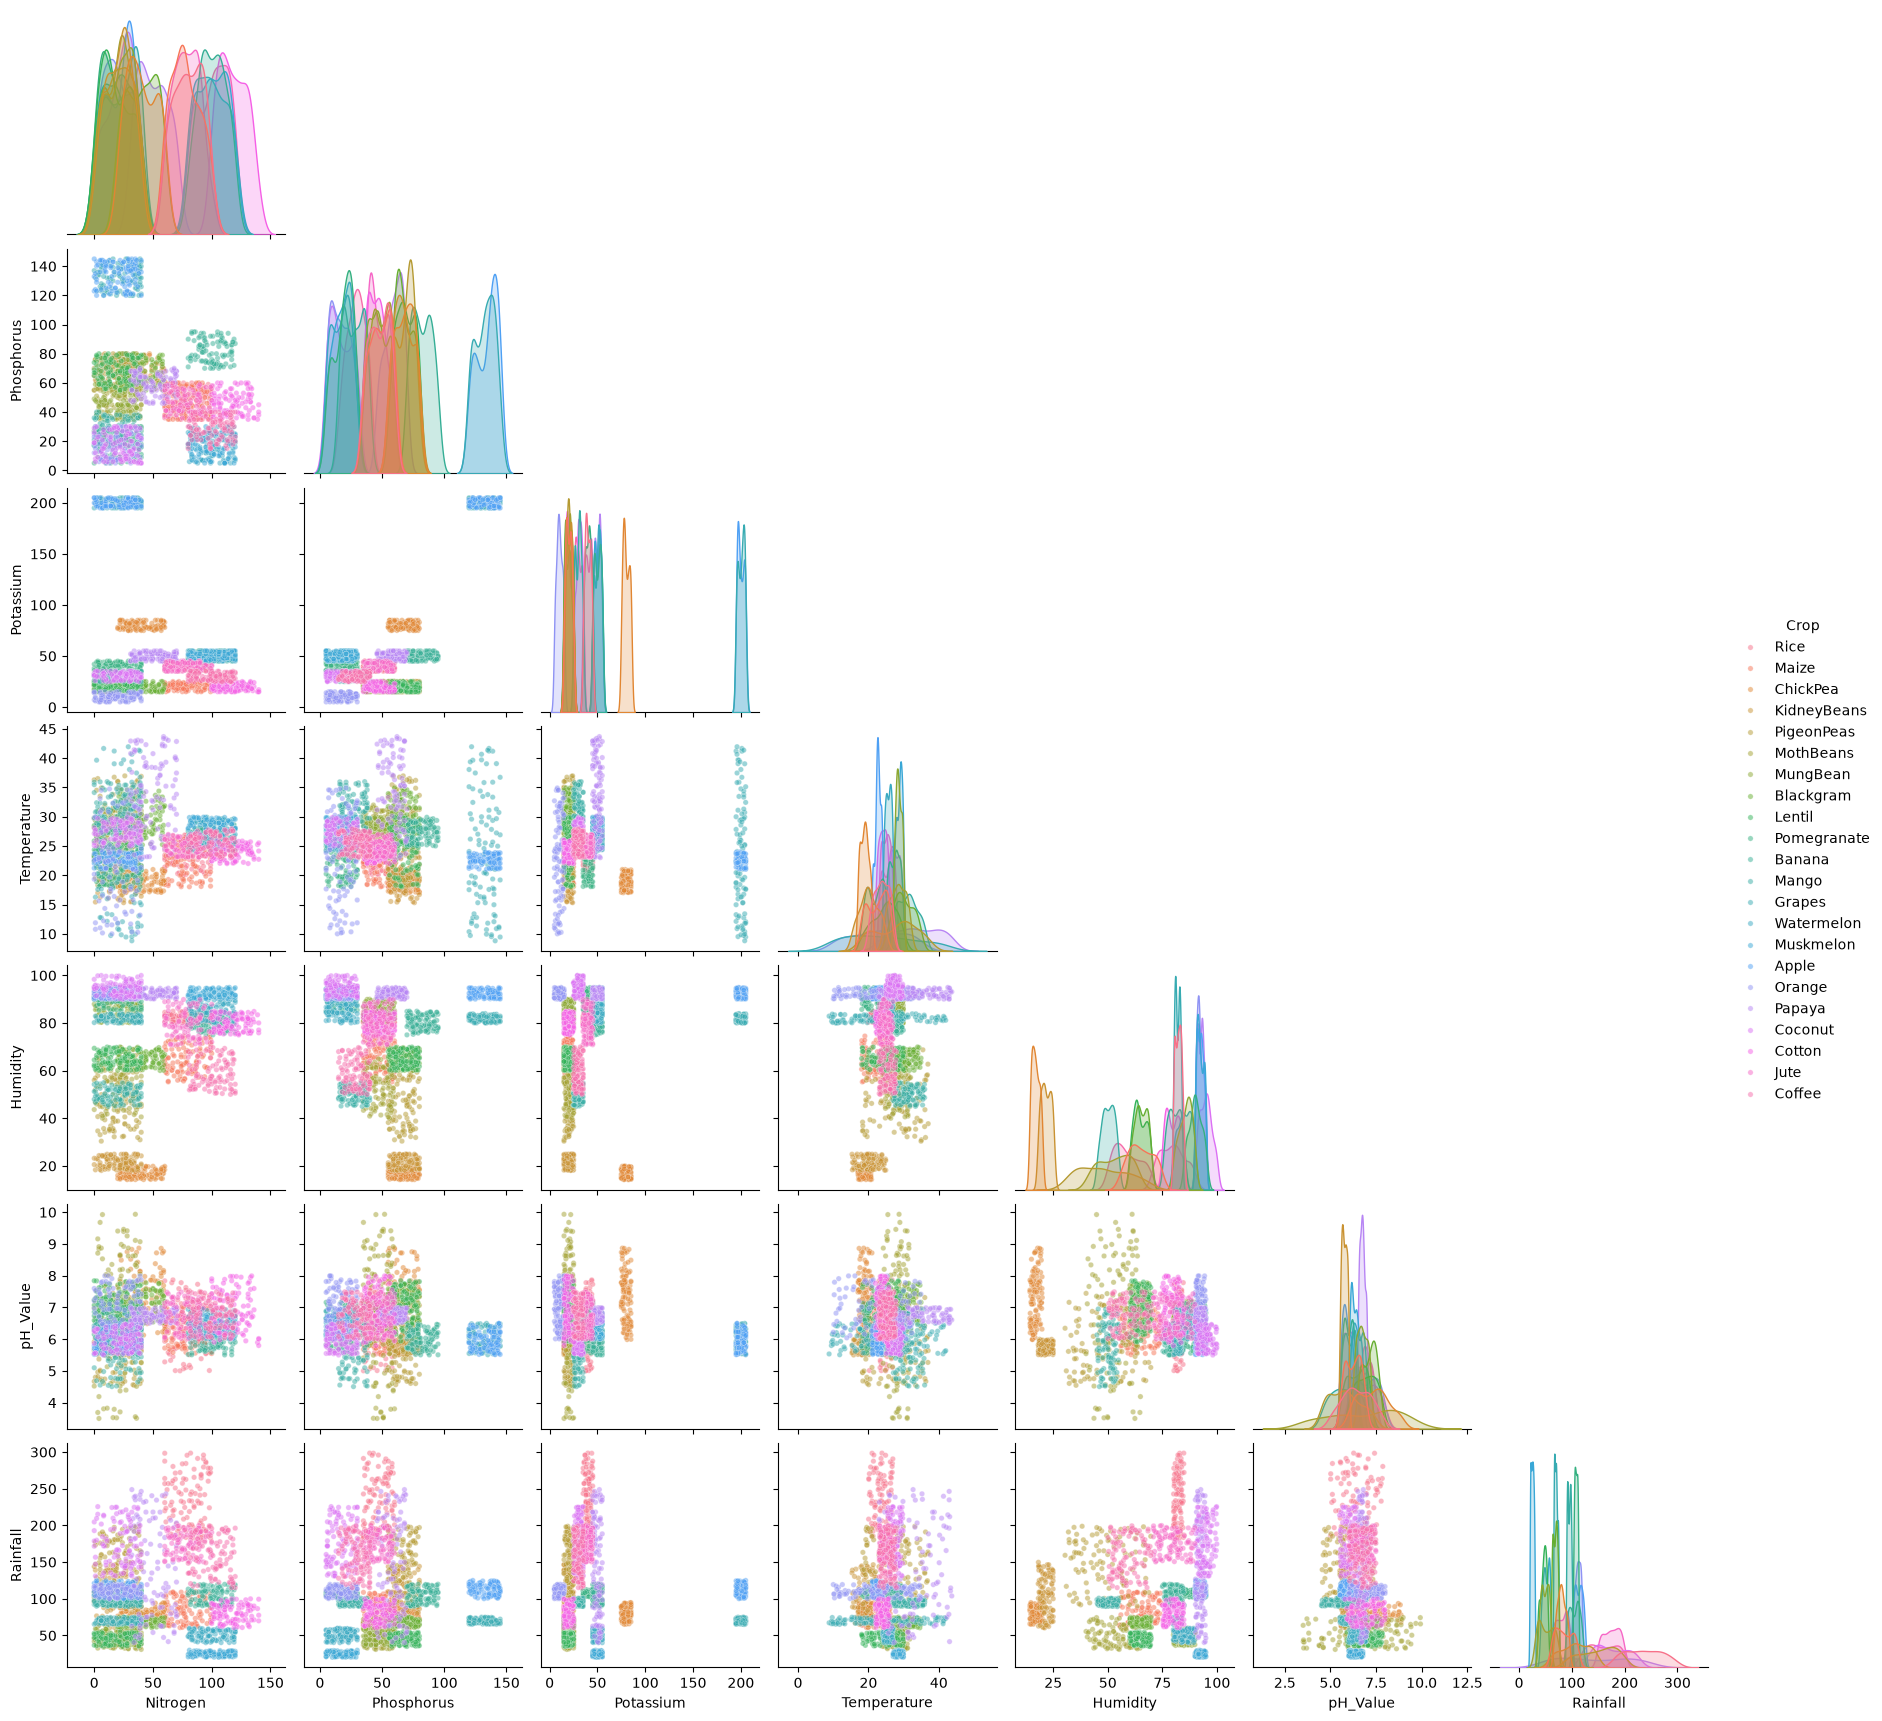

In [62]:
features = [
    "Nitrogen",
    "Phosphorus",
    "Potassium",
    "Temperature",
    "Humidity",
    "pH_Value",
    "Rainfall"
]

sns.pairplot(
    df,
    vars=features,
    hue="Crop",
    corner=True,
    plot_kws={"alpha": 0.5, "s": 15}
)

plt.show()

In [63]:
apple = df[df["Crop"] == "Apple"][features].describe().T
apple

,count,mean,std,min,25%,50%,75%,max
Nitrogen,100.0,20.800000,11.863704,0.000000,10.000000,24.000000,30.000000,40.000000
Phosphorus,100.0,134.220000,8.139665,120.000000,126.750000,136.500000,141.000000,145.000000
Potassium,100.0,199.890000,3.320871,195.000000,197.000000,200.000000,203.000000,205.000000
Temperature,100.0,22.630942,0.827404,21.036527,22.163206,22.628290,23.344066,23.996862
Humidity,100.0,92.333383,1.458551,90.025751,90.970127,92.416541,93.509252,94.920481
pH_Value,100.0,5.929663,0.268932,5.514253,5.705800,5.885818,6.135616,6.499227
Rainfall,100.0,112.654779,7.102985,100.117344,106.070135,112.979230,118.449546,124.983162


### We found that Apple is easily identified

In [64]:
comparison = df.groupby("Crop")[features].mean()

comparison.loc["Apple"].sort_values()

pH_Value         5.929663
Nitrogen        20.800000
Temperature     22.630942
Humidity        92.333383
Rainfall       112.654779
Phosphorus     134.220000
Potassium      199.890000
Name: Apple, dtype: float64

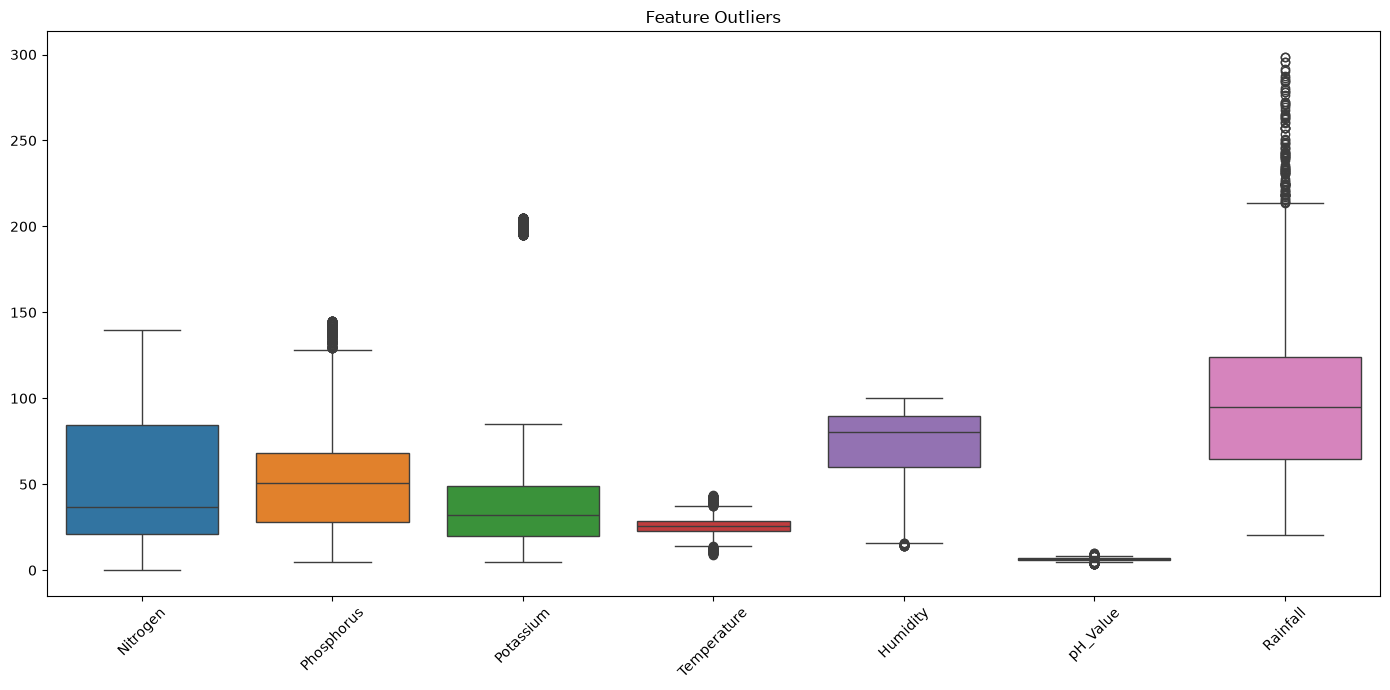

In [65]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df[features])
plt.xticks(rotation=45)
plt.title("Feature Outliers")
plt.tight_layout()
plt.show()

In [66]:
df.nlargest(10, "Rainfall")[["Crop", "Rainfall"]]

,Crop,Rainfall
43,Rice,298.560117
38,Rice,298.401847
96,Rice,295.924880
72,Rice,295.609449
19,Rice,291.298662
90,Rice,290.679378
97,Rice,287.576693
54,Rice,286.508373
37,Rice,285.249365
12,Rice,284.436457


In [67]:
df.nlargest(10, "Potassium")[["Crop", "Potassium"]]

,Crop,Potassium
1202,Grapes,205
1211,Grapes,205
1217,Grapes,205
1225,Grapes,205
1263,Grapes,205
1270,Grapes,205
1280,Grapes,205
1502,Apple,205
1506,Apple,205
1507,Apple,205
